In [ ]:
!pip install -q imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)


from imblearn.over_sampling import SMOTE


pd.set_option("display.max_columns", None)


sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os
from google.colab import files

file_path = "creditcard.csv"



if not os.path.exists(file_path):
    print(f"File '{file_path}' not found. Please upload it now.")
    uploaded = files.upload()
    if file_path not in uploaded:
        raise FileNotFoundError(f"'{file_path}' was not uploaded. Please ensure you upload the correct file.")
    print(f"File '{file_path}' uploaded successfully.")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [6]:
print("\nDataset Shape:")
print(df.shape)
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)


Dataset Shape:
(284807, 31)
Number of Rows: 284807
Number of Columns: 31


In [7]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [9]:
print("Missing Values in Each Column:")
missing_values = df.isnull().sum()

display(missing_values)
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Missing Values in Each Column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Total Missing Values: 0


In [10]:
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)
print("Duplicates remaining:", df.duplicated().sum())


Total Missing Values: 0
Number of Duplicate Records: 1081
Duplicates remaining: 1081


In [11]:
print("Class Distribution:")
print(df["Class"].value_counts())
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentage)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


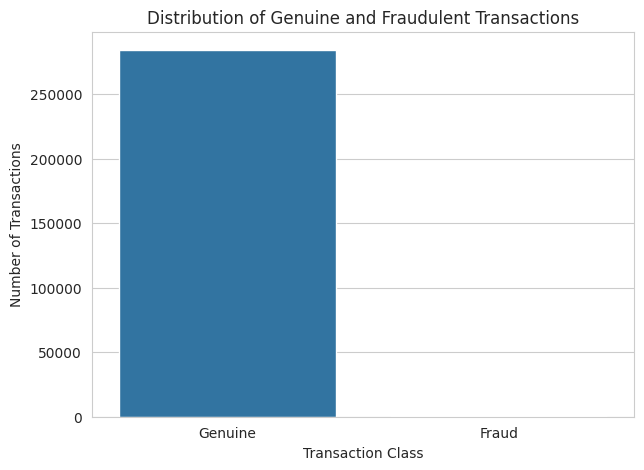

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Distribution of Genuine and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

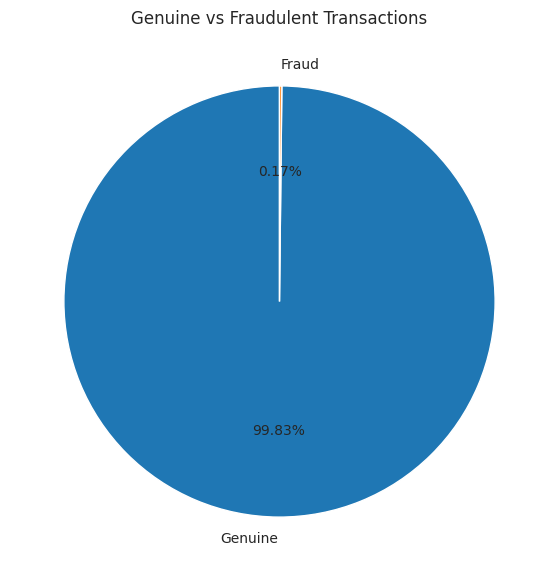

In [13]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    class_counts,
    labels=["Genuine", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Genuine vs Fraudulent Transactions")

plt.show()

Transaction Amount Statistics:


,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


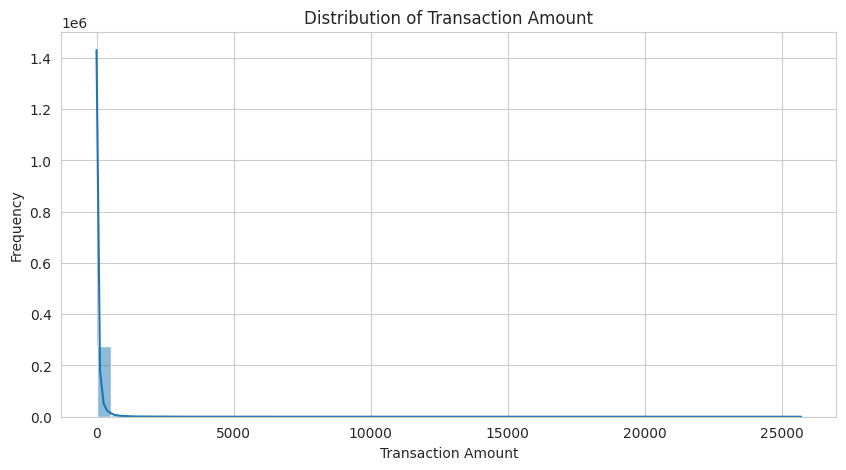

In [14]:
print("Transaction Amount Statistics:")
display(df["Amount"].describe())
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

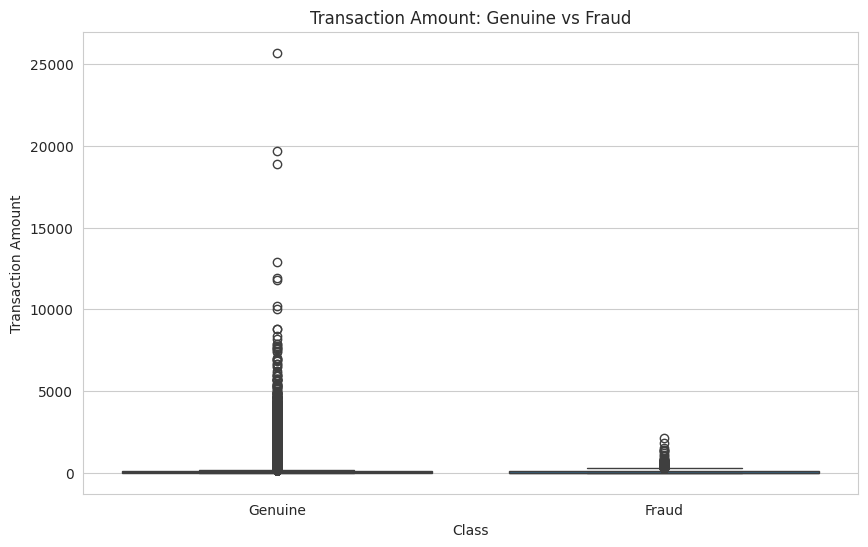

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount: Genuine vs Fraud")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

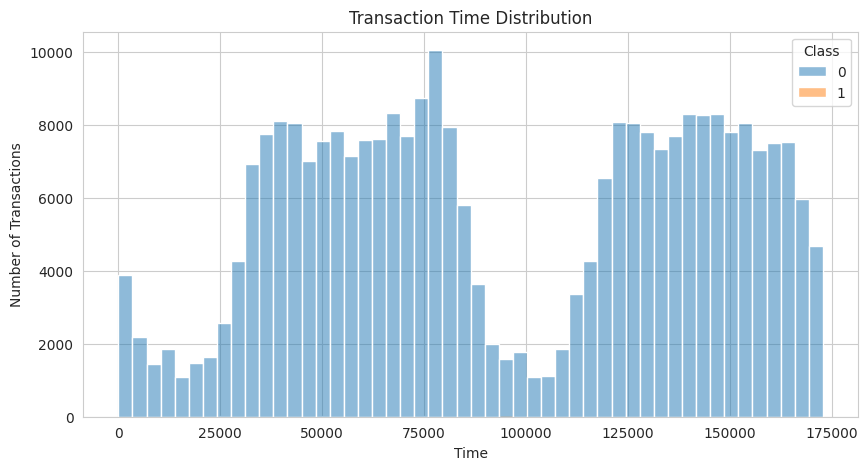

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

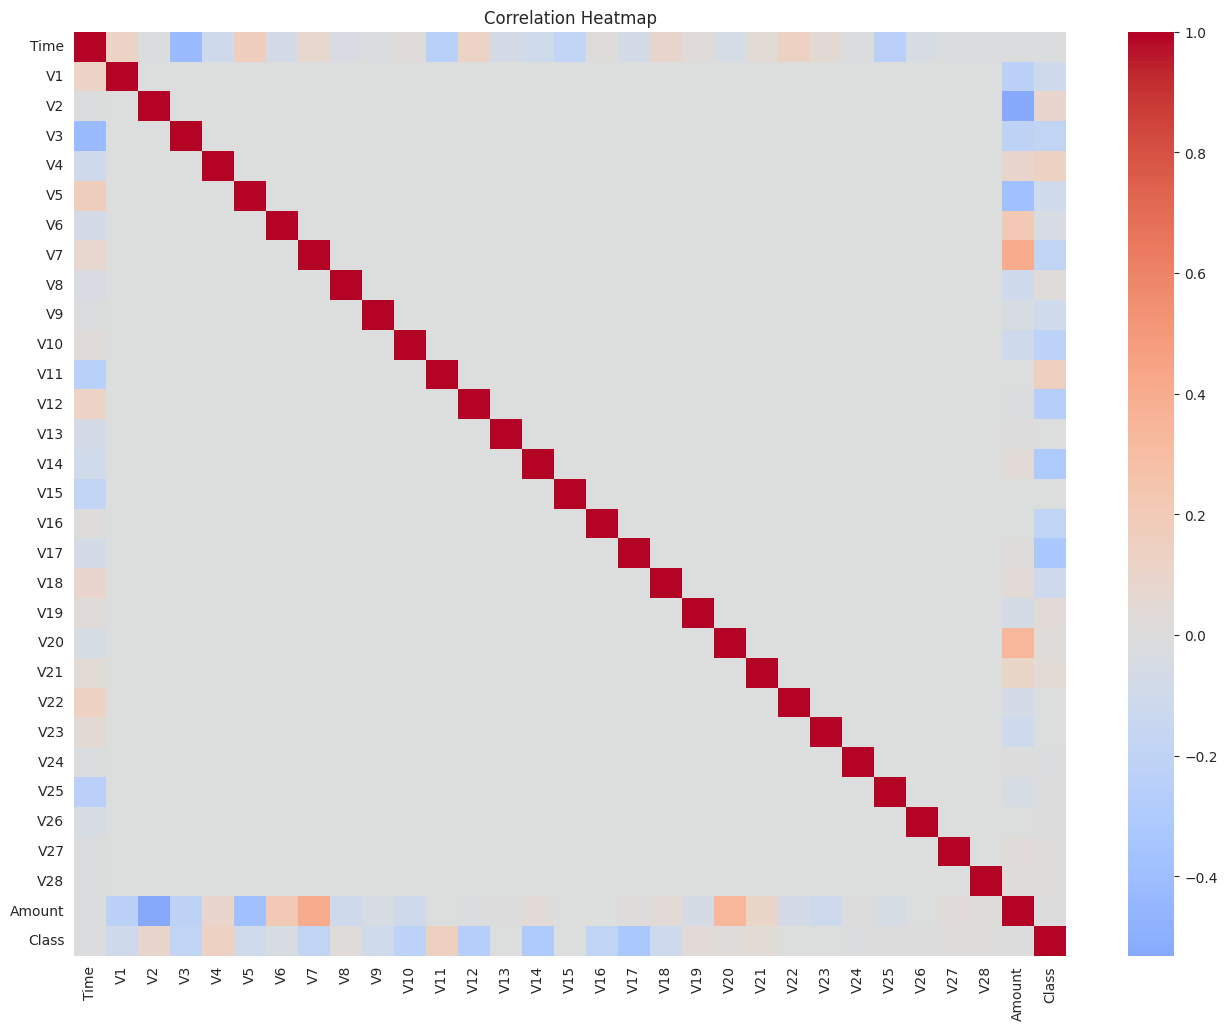

In [17]:
correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

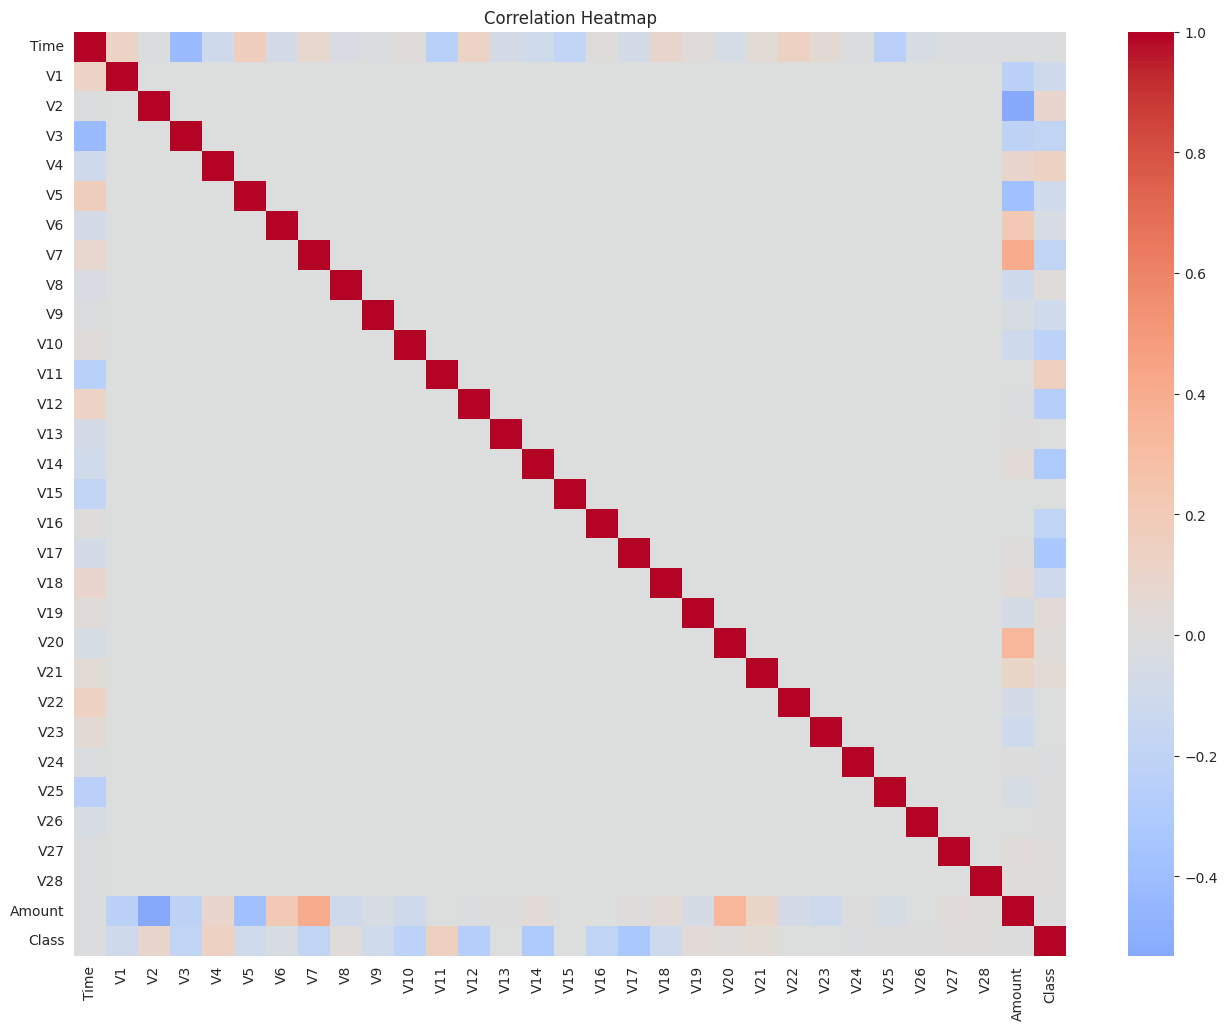

In [18]:
correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
X = df.drop("Class", axis=1)

y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)
Features Shape: (284807, 30)
Target Shape: (284807,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (227845, 30)
Testing Features: (56962, 30)
Training Target: (227845,)
Testing Target: (56962,)


Class distribution before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


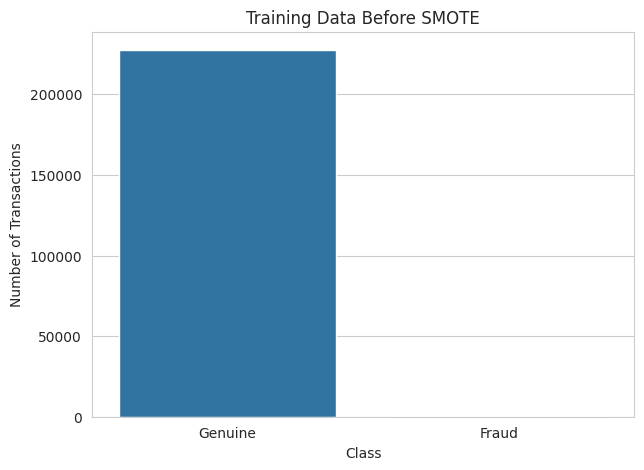

In [21]:
print("Class distribution before SMOTE:")

print(y_train.value_counts())
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train
)

plt.title("Training Data Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

In [22]:
smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [23]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


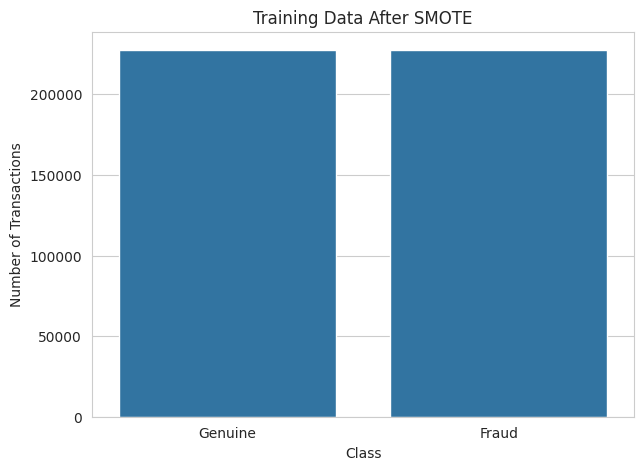

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_resampled
)

plt.title("Training Data After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train_resampled
)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression completed!")

Logistic Regression completed!


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    zero_division=0
)

print("========== LOGISTIC REGRESSION ==========")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_pred,
        zero_division=0
    )
)

========== LOGISTIC REGRESSION ==========
Accuracy: 0.9898528843790597
Precision: 0.13414634146341464
Recall: 0.8979591836734694
F1 Score: 0.23342175066312998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



Confusion Matrix:
[[56296   568]
 [   10    88]]


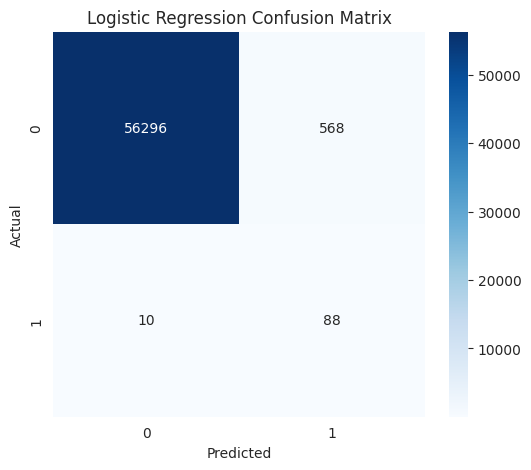

In [28]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

print("Confusion Matrix:")
print(lr_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

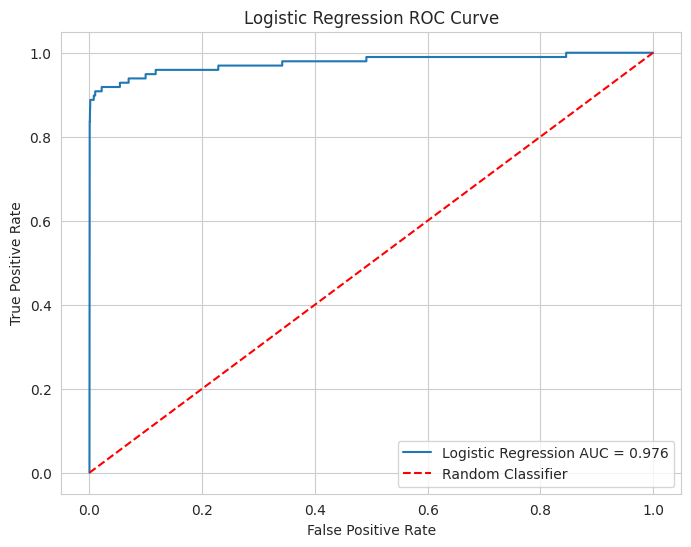

Logistic Regression ROC-AUC: 0.9764816590676788


In [29]:
from sklearn.metrics import roc_curve, auc

lr_fpr, lr_tpr, lr_thresholds = roc_curve(
    y_test,
    lr_prob
)

lr_auc = auc(
    lr_fpr,
    lr_tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression AUC = {lr_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "r--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.show()

print("Logistic Regression ROC-AUC:", lr_auc)

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_resampled,
    y_train_resampled
)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [32]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    zero_division=0
)

print("========== DECISION TREE ==========")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_pred,
        zero_division=0
    )
)

========== DECISION TREE ==========
Accuracy: 0.9977879990168884
Precision: 0.42391304347826086
Recall: 0.7959183673469388
F1 Score: 0.5531914893617021

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.80      0.55        98

    accuracy                           1.00     56962
   macro avg       0.71      0.90      0.78     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix:
[[56758   106]
 [   20    78]]


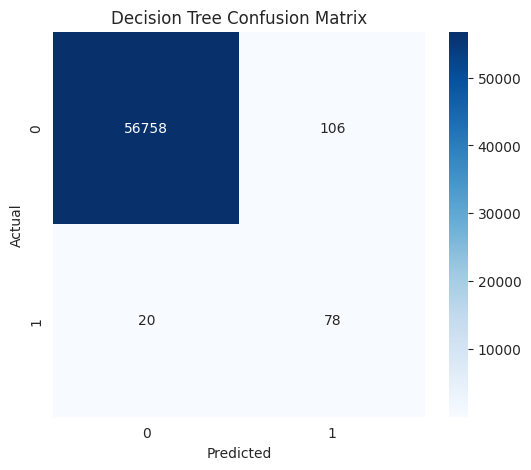

In [33]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print("Confusion Matrix:")
print(dt_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

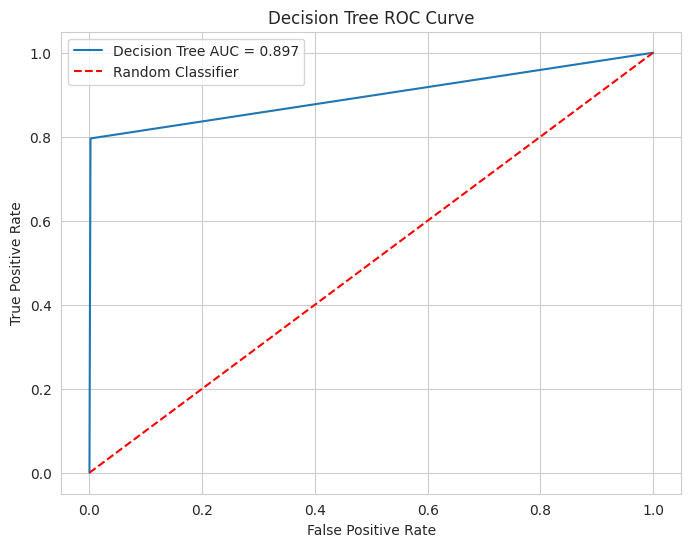

Decision Tree ROC-AUC: 0.897027135277296


In [34]:
dt_fpr, dt_tpr, dt_thresholds = roc_curve(
    y_test,
    dt_prob
)

dt_auc = auc(
    dt_fpr,
    dt_tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree AUC = {dt_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "r--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

print("Decision Tree ROC-AUC:", dt_auc)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_resampled,
    y_train_resampled
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [45]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

print("========== RANDOM FOREST ==========")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

========== RANDOM FOREST ==========
Accuracy: 0.999403110845827
Precision: 0.826530612244898
Recall: 0.826530612244898
F1 Score: 0.826530612244898

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Random Forest Confusion Matrix:
[[56847    17]
 [   17    81]]


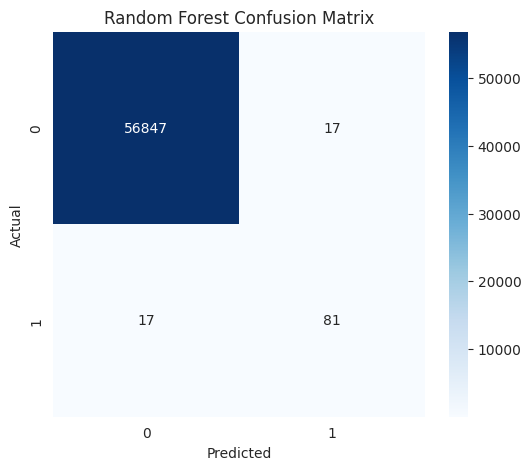

In [46]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

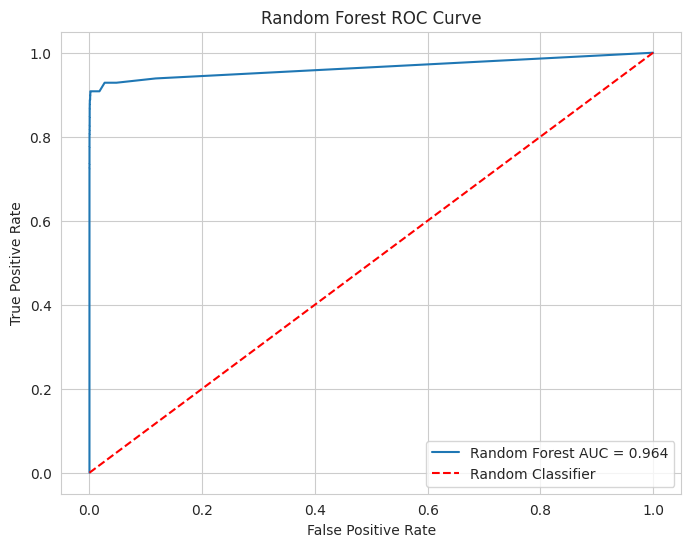

Random Forest ROC-AUC: 0.9644234399584257


In [47]:
rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    rf_prob
)

rf_auc = auc(
    rf_fpr,
    rf_tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "r--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

print("Random Forest ROC-AUC:", rf_auc)

In [48]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

print("========== FINAL MODEL COMPARISON ==========")

display(results)

========== FINAL MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.989853,0.134146,0.897959,0.233422,0.976482
1,Decision Tree,0.997788,0.423913,0.795918,0.553191,0.897027
2,Random Forest,0.999403,0.826531,0.826531,0.826531,0.964423


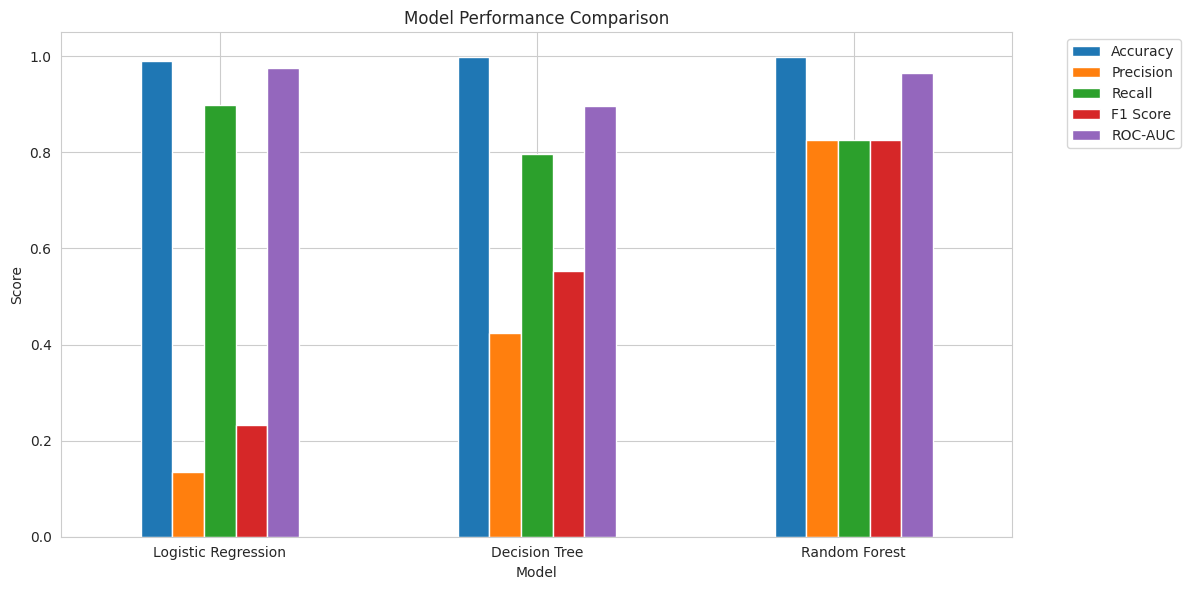

In [49]:
results_plot = results.set_index(
    "Model"
)

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

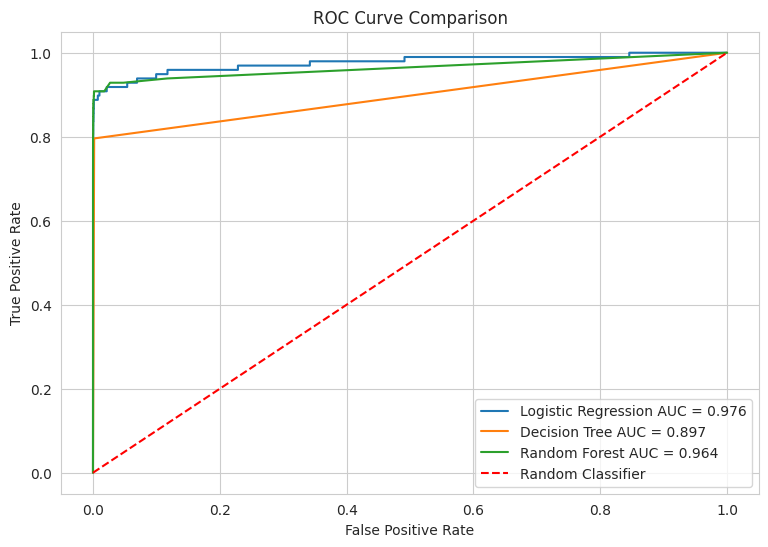

In [50]:
plt.figure(figsize=(9, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression AUC = {lr_auc:.3f}"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree AUC = {dt_auc:.3f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "r--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [51]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")

display(
    importance_df.head(10)
)

Top 10 Important Features:


,Feature,Importance
14,V14,0.216978
10,V10,0.119804
4,V4,0.116792
12,V12,0.107548
17,V17,0.086269
3,V3,0.070823
11,V11,0.050492
16,V16,0.040146
2,V2,0.038889
9,V9,0.028260


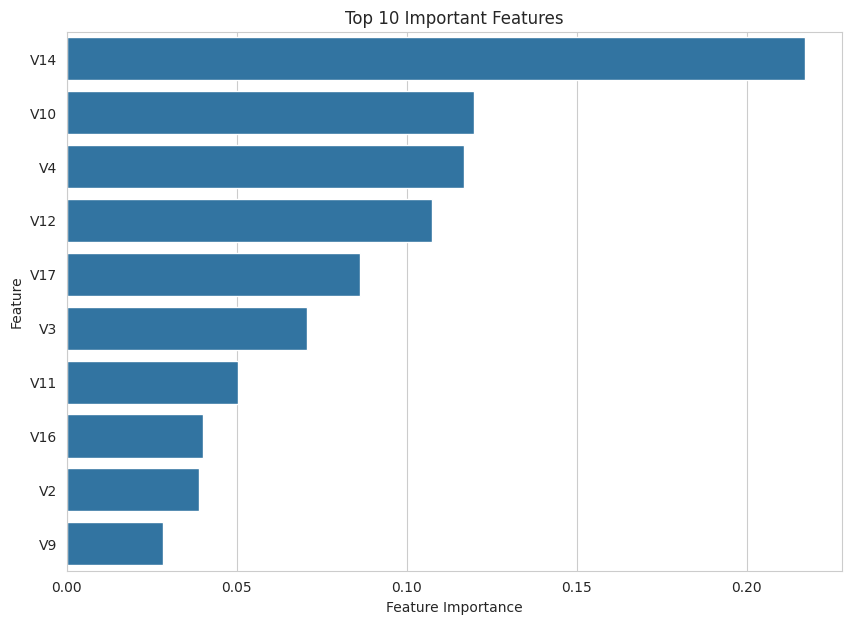

In [52]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [53]:
best_accuracy = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_precision = results.loc[
    results["Precision"].idxmax(),
    "Model"
]

best_recall = results.loc[
    results["Recall"].idxmax(),
    "Model"
]

best_f1 = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_auc = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model based on Accuracy:", best_accuracy)
print("Best Model based on Precision:", best_precision)
print("Best Model based on Recall:", best_recall)
print("Best Model based on F1 Score:", best_f1)
print("Best Model based on ROC-AUC:", best_auc)

Best Model based on Accuracy: Random Forest
Best Model based on Precision: Random Forest
Best Model based on Recall: Logistic Regression
Best Model based on F1 Score: Random Forest
Best Model based on ROC-AUC: Logistic Regression


In [54]:
print("========== CREDIT CARD FRAUD DETECTION ==========")

print("\nLogistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("ROC-AUC:", lr_auc)

print("\nDecision Tree")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)
print("ROC-AUC:", dt_auc)

print("\nRandom Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_auc)

========== CREDIT CARD FRAUD DETECTION ==========

Logistic Regression
Accuracy: 0.9898528843790597
Precision: 0.13414634146341464
Recall: 0.8979591836734694
F1 Score: 0.23342175066312998
ROC-AUC: 0.9764816590676788

Decision Tree
Accuracy: 0.9977879990168884
Precision: 0.42391304347826086
Recall: 0.7959183673469388
F1 Score: 0.5531914893617021
ROC-AUC: 0.897027135277296

Random Forest
Accuracy: 0.999403110845827
Precision: 0.826530612244898
Recall: 0.826530612244898
F1 Score: 0.826530612244898
ROC-AUC: 0.9644234399584257
